In [57]:
from chemplot import Plotter
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDetermineBonds
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import math
import re

import subprocess, sys

Load the dataset

In [2]:
alf = pd.read_csv("./ALFABET_data/acp_new.csv")
alf

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,PID,Parent,Index,Child1,Child2,BDE,Bond,Heavy
0,0,0,0,1,NCCCC(=O)O,0,[CH2]CCC(=O)O,[NH2],86.584384,C-N,7.0
1,1,1,1,2,NCCCC(=O)O,1,[CH2]CC(=O)O,[CH2]N,83.222816,C-C,7.0
2,2,2,2,3,NCCCC(=O)O,2,[CH2]C(=O)O,[CH2]CN,87.547611,C-C,7.0
3,3,3,3,4,NCCCC(=O)O,3,O=[C]O,[CH2]CCN,95.963768,C-C,7.0
4,4,4,4,5,NCCCC(=O)O,5,NCCC[C]=O,[OH],111.470155,C-O,7.0
...,...,...,...,...,...,...,...,...,...,...,...
478268,478268,478268,478268,849896,C=CCC#N,4,[H],[CH]=CCC#N,111.743121,C-H,5.0
478269,478269,478269,478269,849897,C=CCC#N,5,[H],[CH]=CCC#N,111.743121,C-H,5.0
478270,478270,478270,478270,849898,C=CCC#N,6,[H],C=[C]CC#N,109.405021,C-H,5.0
478271,478271,478271,478271,849899,C=CCC#N,7,[H],C=C[CH]C#N,79.573221,C-H,5.0


Plot of bond type frequency

<AxesSubplot:xlabel='Bond-type', ylabel='Frequency'>

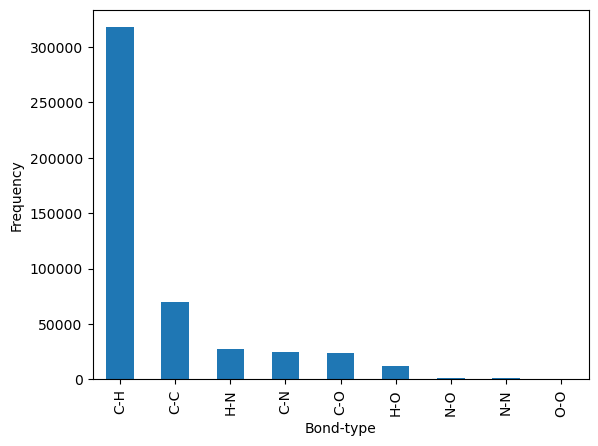

In [3]:
fig, ax = plt.subplots()
alf['Bond'].value_counts().plot(ax=ax, kind='bar', xlabel='Bond-type',ylabel='Frequency')
#plt.savefig("bond_frequency.svg")

Plot of BDE vs bond types

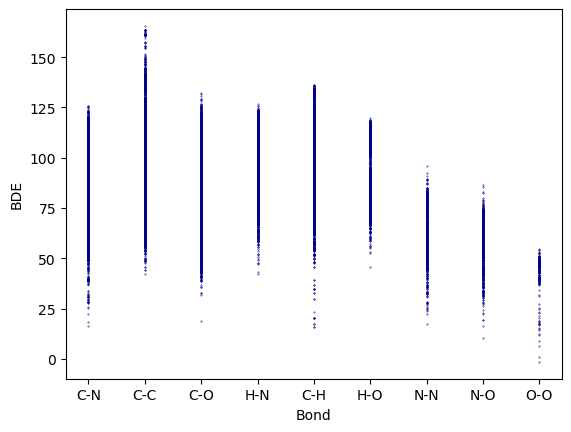

In [4]:
ax1 = alf.plot.scatter(x='Bond',y='BDE',c='DarkBlue', s=0.1)
#plt.savefig("BDEvsBond.svg")

Plot of frequency vs Heavy atoms

<AxesSubplot:xlabel='Heavy atom count', ylabel='Frequency'>

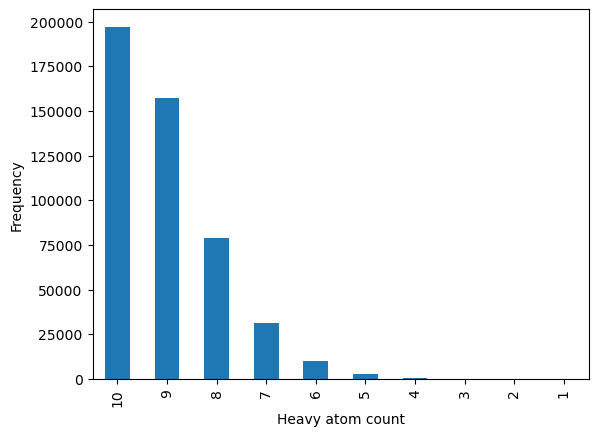

In [5]:
alf.Heavy = alf.Heavy.astype(int)
fig, ax = plt.subplots()
alf['Heavy'].value_counts().plot(ax=ax, kind='bar', xlabel='Heavy atom count',ylabel='Frequency')
#plt.savefig("HeavyFrequency.svg")

TSNE and UMAP plots

In [21]:
from chemplot import Plotter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
#import matplotlib.colors as mcolors

In [7]:
data_BBBP = pd.read_csv("./ALFABET_data/acp_new.csv").head(1000)

In [8]:
cp = Plotter.from_smiles(np.array(data_BBBP["Parent"]),target_type="C")

sim_type indicates the similarity type by which the plots are constructed.
The supported similarity types are structural and tailored.
Because no target list has been provided 'structural' as been selected as sym_type.


In [9]:
a = cp.tsne()

In [10]:
col = (data_BBBP["BDE"]-np.min(data_BBBP["BDE"]))/(np.max(data_BBBP["BDE"])-np.min(data_BBBP["BDE"])) 

[Text(-100.0, 0, ''),
 Text(-50.0, 0, ''),
 Text(0.0, 0, ''),
 Text(50.0, 0, ''),
 Text(100.0, 0, '')]

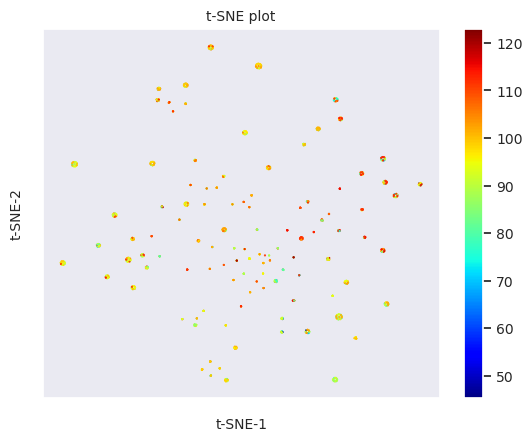

In [43]:
fig, ax = plt.subplots()

cmap = cm.jet(col)
plt.scatter(a['t-SNE-1'], a['t-SNE-2'], s=0.3, c=cmap)

norm = plt.Normalize(np.min(data_BBBP["BDE"]), np.max(data_BBBP["BDE"]))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cm.jet), ax=ax)
#ax.scatter(a['t-SNE-1'], a['t-SNE-2'], s=0.3, c=cm.jet(col))

cbar.ax.tick_params(labelsize=10)
ax.set_xlabel('t-SNE-1', size=10)
ax.set_ylabel('t-SNE-2', size=10)
ax.set_title('t-SNE plot', size=10)

ax.set_yticklabels([])
ax.set_xticklabels([])
#plt.axis('off')

UMAP plots

In [47]:
b = cp.umap()

/home/c/anaconda3/envs/plt/lib/python3.9/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/c/anaconda3/envs/plt/lib/python3.9/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/c/anaconda3/envs/plt/lib/python3.9/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


[Text(-50.0, 0, ''),
 Text(-25.0, 0, ''),
 Text(0.0, 0, ''),
 Text(25.0, 0, ''),
 Text(50.0, 0, '')]

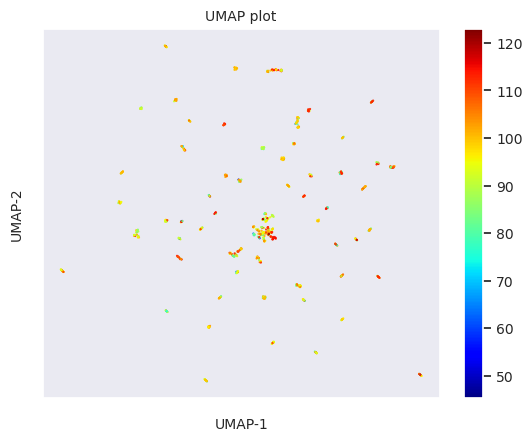

In [46]:
fig, ax = plt.subplots()

cmap = cm.jet(col)
plt.scatter(b['UMAP-1'], b['UMAP-2'], s=0.3, c=cmap)

norm = plt.Normalize(np.min(data_BBBP["BDE"]), np.max(data_BBBP["BDE"]))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cm.jet), ax=ax)
#ax.scatter(a['t-SNE-1'], a['t-SNE-2'], s=0.3, c=cm.jet(col))

cbar.ax.tick_params(labelsize=10)
ax.set_xlabel('UMAP-1', size=10)
ax.set_ylabel('UMAP-2', size=10)
ax.set_title('UMAP plot', size=10)

ax.set_yticklabels([])
ax.set_xticklabels([])
#plt.axis('off')

Load functional groups and display highest occuring ones

In [89]:
#Load .din file (they have no easier ways to check for parents)
count=0
arr = []
with open("ALFABET_data/johnbde.din", 'r') as f1:
    for i in range(4): next(f1)
    for fline in iter(lambda: f1.readline(), ''):
        name = fline.rstrip() + ".sdf"
        for i in range(7): next(f1)

        #print(f"""checkmol {"ALFABET_data/sdf/" + name} | tr '\\n' ',' | sed 's/,$//';echo""")
        
        proc = subprocess.Popen(f"""checkmol {"ALFABET_data/sdf/" + name} | tr '\\n' ',' | sed 's/,$//';echo""", shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        output, error = proc.communicate()
        if (output == None): arr.append(None)
        else: arr.append(output.decode().rstrip())

        #only run 1000 times for simplicity
        count += 1
        if count == 1000: break

In [90]:
print(arr)

['', '', '', '', '', '', '', 'dialkyl ether,heterocyclic compound', 'dialkyl ether,heterocyclic compound', 'dialkyl ether,heterocyclic compound', 'hydrazine derivative,heterocyclic compound', 'peroxide,heterocyclic compound', '', '', '', '', '', '', 'secondary amine,secondary aliphatic amine (dialkylamine),heterocyclic compound', 'secondary amine,secondary aliphatic amine (dialkylamine),heterocyclic compound', 'orthocarboxylic acid derivative,orthoester,heterocyclic compound', 'secondary amine,secondary aliphatic amine (dialkylamine),heterocyclic compound', 'secondary amine,secondary aliphatic amine (dialkylamine),heterocyclic compound', 'dialkyl ether,secondary amine,secondary aliphatic amine (dialkylamine),heterocyclic compound', 'acetal,heterocyclic compound', 'aromatic compound', 'aromatic compound', 'aromatic compound', 'aromatic compound', 'aromatic compound', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', 'alkene', '

In [91]:
def count_frequencies(output):
    frequencies = {}
    frequencies[None] = 0
    for i in output:
        if i == None: 
            frequencies[None] += 1
            continue
        lines = i.split(',')
        for line in lines:
            line = line.strip()
            if line in frequencies:
                frequencies[line] += 1
            else:
                frequencies[line] = 1
    return frequencies

In [92]:
freq = count_frequencies(arr)
for line, count in freq.items():
    print(f"{line}: {count}")

None: 0
: 140
dialkyl ether: 97
heterocyclic compound: 456
hydrazine derivative: 4
peroxide: 9
secondary amine: 131
secondary aliphatic amine (dialkylamine): 91
orthocarboxylic acid derivative: 1
orthoester: 1
acetal: 28
aromatic compound: 192
alkene: 521
enol ether: 40
secondary aliphatic/aromatic amine (alkylarylamine): 40
hemiaminal: 14
enamine: 36
imine: 30
carboxylic acid amidine: 5
tertiary amine: 10
tertiary aliphatic amine (trialkylamine): 10
aminal: 9
oxime ether: 5
ketene acetal or derivative: 8
azo compound: 3
diaryl ether: 3
alkyl aryl ether: 11


{'alkene': 521, 'heterocyclic compound': 456, 'aromatic compound': 192, 'secondary amine': 131, 'dialkyl ether': 97}


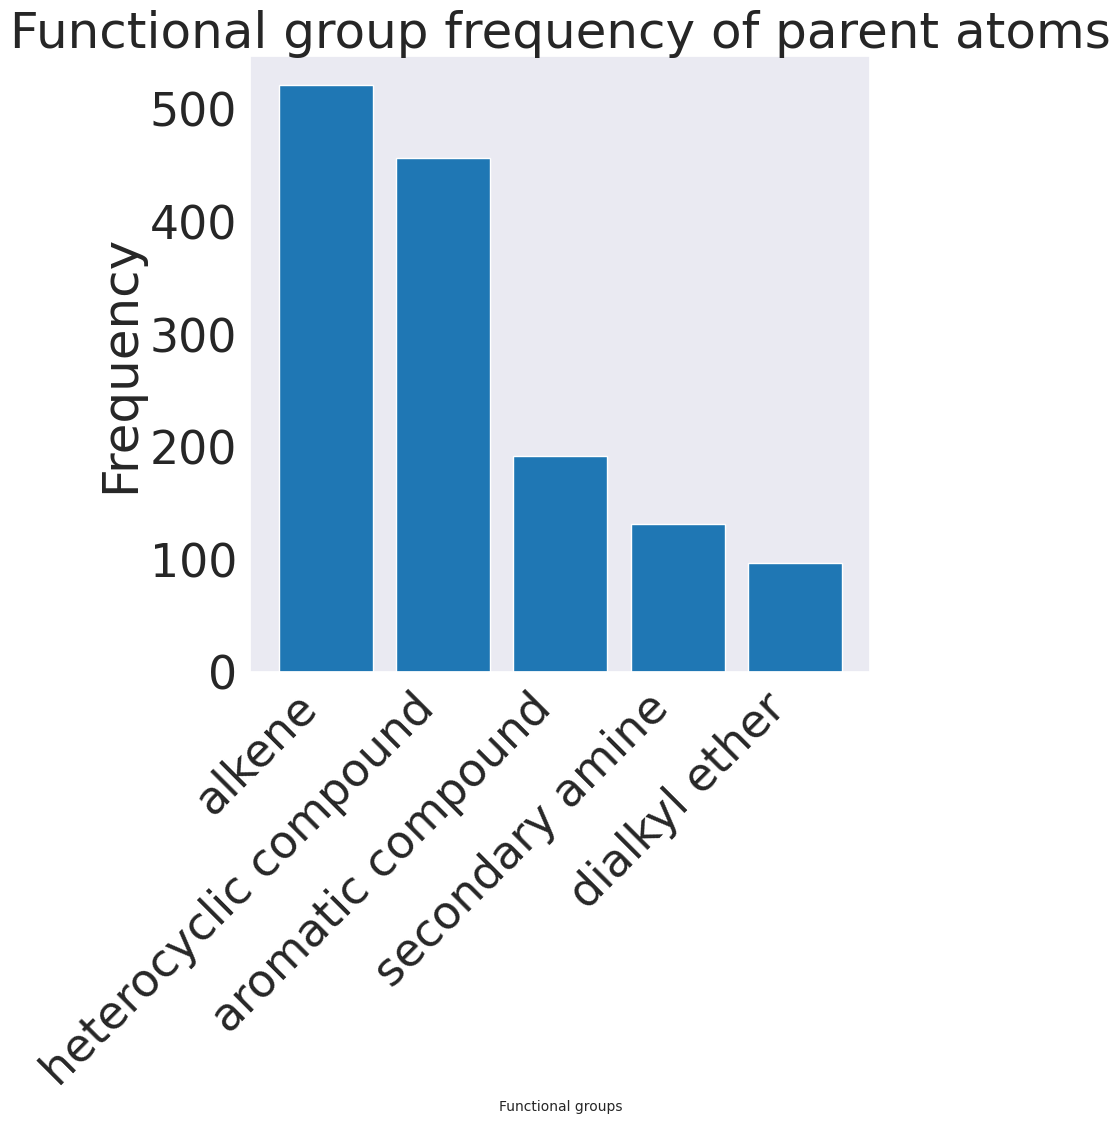

In [112]:
datapointno = 5

top5 = {k:v for k,v in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:datapointno]}
print(top5)
plt.figure(figsize=(8,8))
plt.bar(top5.keys(), top5.values())
plt.xticks(rotation=45, ha = 'right')
plt.xlabel('Functional groups', size=10)
plt.ylabel('Frequency')
plt.title(f'Functional group frequency of parent atoms')
plt.show()

Distribution of pairwise bond lengths

In [120]:
def computedistance(index1, index2, positions):
    return math.sqrt(((positions[index1][0] - positions[index2][0])**2) + ((positions[index1][1] - positions[index2][1])**2) + ((positions[index1][2] - positions[index2][2])**2))

In [133]:

def logmoldistances(mol, dfset):
    #for every bond, compute distance, log it alongside bond-type
    mol = Chem.Mol(mol)
    arr = mol.GetConformer().GetPositions()

    for bonds in mol.GetBonds():
        frag = mol.GetAtomWithIdx(bonds.GetBeginAtomIdx()).GetSymbol() + '-' + mol.GetAtomWithIdx(bonds.GetEndAtomIdx()).GetSymbol()
        print(str(bonds.GetIdx()) + ", " + str(frag))
        if frag not in dfset:
            dfset[frag] = pd.DataFrame(columns=['BondType', 'Distance'])
        
        dfset[frag].loc[len(dfset[frag])] = [frag] + [computedistance(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx(), arr)]
        #df.loc[count] = [frag] + [computedistance(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx(), arr)]
        #print(bonds.GetBeginAtomIdx(), bonds.GetEndAtomIdx())
        #count = count + 1
    

In [134]:
mol = Chem.MolFromMolFile("ALFABET_data/sdf/johnbde_006292.sdf", removeHs=False)
df3 = {}
logmoldistances(mol, df3)

0, C-H
1, C-C
2, C-C
3, C-H
4, C-C
5, C-C
6, C-C
7, C-H
8, C-C
9, C-C
10, C-H
11, C-C
12, C-H
13, C-H
14, C-C
15, C-H
16, C-C
17, C-C
18, C-C
19, C-H


In [ ]:
count=0
with open("ALFABET_data/johnbde.din", 'r') as f1:
    for i in range(4): next(f1)
    for fline in iter(lambda: f1.readline(), ''):
        name = fline.rstrip() + ".sdf"
        for i in range(7): next(f1)

        #TODO parse function output for easy plotting

        #only run 50 times for simplicity
        count += 1
        if count == 50: break

In [137]:
print(df3)

{'C-H':   BondType  Distance
0      C-H  1.086521
1      C-H  1.086406
2      C-H  1.086558
3      C-H  1.086459
4      C-H  1.086406
5      C-H  1.086405
6      C-H  1.086459
7      C-H  1.086446, 'C-C':    BondType  Distance
0       C-C  1.559613
1       C-C  1.559636
2       C-C  1.559547
3       C-C  1.559608
4       C-C  1.559650
5       C-C  1.559527
6       C-C  1.559453
7       C-C  1.559650
8       C-C  1.559630
9       C-C  1.559644
10      C-C  1.559562
11      C-C  1.559666}


In [144]:
df3.keys()

dict_keys(['C-H', 'C-C'])

In [153]:
print(df3['C-H'].iat[0,1])


1.0865205750467866


In [36]:
df2['C-H']['Distance'].mean()

1.0922067905335078

BDE vs. Heavy atoms

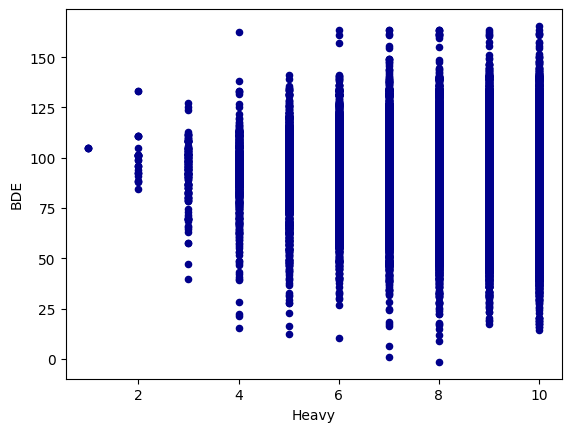

In [91]:
ax1 = alf.plot.scatter(x='Heavy',y='BDE',c='DarkBlue', s=1)